In [5]:
import pandas as pd


In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '../Data/Bus/Converted_Fare.xlsx'
df_converted_fare = pd.read_excel(file_path, engine='openpyxl')
df_converted_fare.head()

,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,LAST_UPDATE_DATE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,...,ON_SEQ_STOP_ID,STOP_SEQ_y,STOP_NAMES_y,OFF_SEQ_STOP_ID,ON_SEQ_STOP_X,ON_SEQ_STOP_Y,OFF_SEQ_STOP_X,OFF_SEQ_STOP_Y,ON_DISTRICT,OFF_DISTRICT
0,1000193,2,1,5,63.7,2024-10-16,DB08R,DB,N,0,...,359,5,愉景湾道安澄阁外,12777,834216,816529,819213,818784,中西區,離島
1,1000193,2,1,6,63.7,2024-10-16,DB08R,DB,N,0,...,359,6,愉景湾道时峰对面,12778,834216,816529,819066,818684,中西區,離島
2,1000193,2,1,7,63.7,2024-10-16,DB08R,DB,N,0,...,359,7,愉景湾道峻山阁对面,12779,834216,816529,819066,818478,中西區,離島
3,1000193,2,1,8,63.7,2024-10-16,DB08R,DB,N,0,...,359,8,愉景湾道明翠台外,12780,834216,816529,819174,818162,中西區,離島
4,1000193,2,1,9,63.7,2024-10-16,DB08R,DB,N,0,...,359,9,愉景湾道海燕径第 15 座外,12781,834216,816529,819451,817572,中西區,離島


In [56]:
df_converted_fare['SERVICE_MODE'].unique()

array(['N', 'NT', 'T', 'R'], dtype=object)

e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
e:\Users\非衣\AppData\Local\P

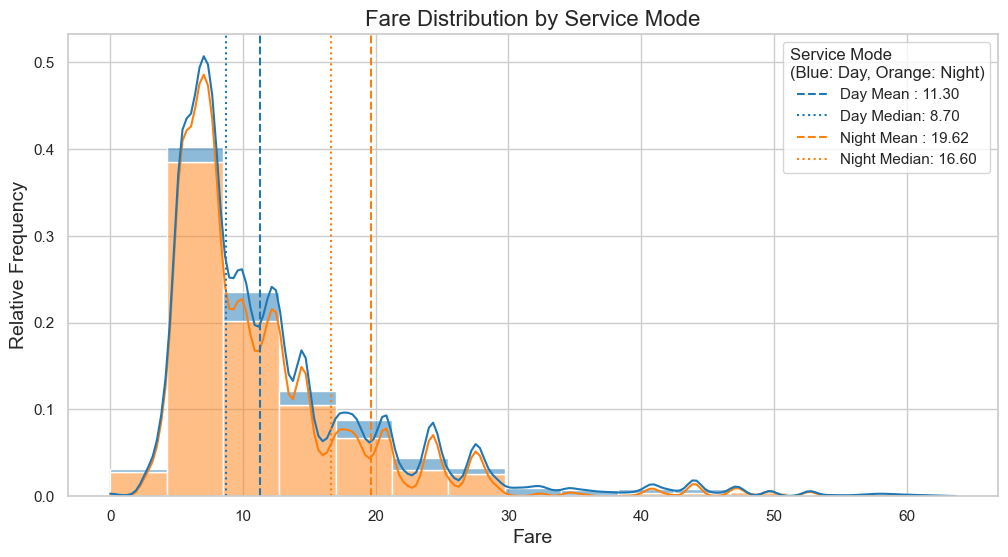

In [57]:
df_converted_fare['SERVICE_MODE'] = df_converted_fare['SERVICE_MODE'].replace({'N': 'Night', 'NT': 'Night', 'R': 'Day', 'T': 'Day'})

# 计算统计值
mode_stats = df_converted_fare.groupby('SERVICE_MODE')['PRICE'].agg(['mean', 'median', 'min', 'max']).reset_index()

# 设置绘图风格
sns.set(style='whitegrid')

# 创建直方图，纵坐标为相对频率
plt.figure(figsize=(12, 6))
palette = ['#1f77b4', '#ff7f0e']
sns.histplot(data=df_converted_fare, x='PRICE', bins=15, kde=True, hue='SERVICE_MODE', multiple='stack', alpha=0.5, palette=palette, stat='probability')

# 添加统计信息
for mode, color in zip(['Day', 'Night'], palette):
    mean_price = df_converted_fare[df_converted_fare['SERVICE_MODE'] == mode]['PRICE'].mean()
    median_price = df_converted_fare[df_converted_fare['SERVICE_MODE'] == mode]['PRICE'].median()
    
    plt.axvline(mean_price, linestyle='--', label=f'{mode} Mean : {mean_price:.2f}', color=color)
    plt.axvline(median_price, linestyle=':', label=f'{mode} Median: {median_price:.2f}', color=color)


# 添加标题和标签
plt.title('Fare Distribution by Service Mode', fontsize=16)
plt.xlabel('Fare', fontsize=14)
plt.ylabel('Relative Frequency', fontsize=14)

# 添加图例
plt.legend(title='Service Mode\n(Blue: Day, Orange: Night)')
plt.show()

In [19]:
file_path_2 = '../Data/Factors/DC_21C.CSV'
df_factor = pd.read_csv(file_path_2).head(22)
df_factor.head()

,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2
0,District Council district (class),District Council district,Name of District Council district (in English),Name of District Council district (in Chinese),Total population,Population by sex,Population by sex,Sex ratio (i.e. the number of males per 1 000 ...,Population by age group,Population by age group,...,Median monthly domestic household rent (HK$),Median monthly domestic household rent to inco...,Median floor area of accommodation of domestic...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over not having internal...,Population aged 5 and over not having internal...,Population aged 5 and over not having internal...
1,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,男性,女性,性別比率（即男性數目與每千名女性相對的比率）,15歲以下,15至24歲,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),香港島,九龍,新市鎮,新界其他地區／水上,曾在同區遷居,仍居舊址(23),居於香港以外地方
2,District Council district (class),District Council district,Name of District Council district (in English),Name of District Council district (in Chinese),Total population,Male,Female,Sex ratio (i.e. the number of males per 1 000 ...,< 15,15 - 24,...,Median monthly domestic household rent (HK$),Median monthly domestic household rent to inco...,Median floor area of accommodation of domestic...,Hong Kong Island,Kowloon,New towns,Other areas in the New Territories/ Marine,Moved home within same area of residence,Remained in same address(23),Place of residence outside Hong Kong
3,dc_class,dc,dc_eng,dc_chi,t_pop,pop_m,pop_f,sr,age_1,age_2,...,dm_r,dmr_ir,fa_m,pm_hk,pm_kln,pm_nt,pm_oth,pm_samearea,pm_same,pm_out
4,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,15070,28,41,9932,5408,5799,1562,26614,153665,25390


In [20]:
df_factor.head(10)
len(df_factor)

22

In [21]:
df_factor = df_factor.drop(index=[0, 1, 2, 3]).reset_index(drop=True)
df_factor.head()

,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2
0,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,15070,28,41,9932,5408,5799,1562,26614,153665,25390
1,B,12,Wan Chai,灣仔區,166695,67075,99620,673,16917,9907,...,16300,28.1,47,11587,4978,4826,1132,17262,104927,16873
2,C,13,Eastern,東區,529603,233542,296061,789,51517,36336,...,3520,19.3,44,15299,8426,10529,2079,46515,406489,26276
3,D,14,Southern,南區,263278,116239,147039,791,27255,18842,...,2850,15.7,41,10450,4560,4128,1508,20782,200203,14426
4,E,27,Yau Tsim Mong,油尖旺區,310647,138873,171774,808,36181,23224,...,7000,32,37,6925,14591,13189,2361,32320,197542,31863


In [22]:
df_factor.columns

Index(['區議會分區（分組)', '區議會分區', '區議會分區（英文名稱)', '區議會分區（中文名稱)', '總人口', '按性別劃分的人口',
       '按性別劃分的人口.1', '性別比率（即男性數目與每千名女性相對的比率）', '按年齡組別劃分的人口', '按年齡組別劃分的人口.1',
       ...
       '家庭住戶每月租金（港元）中位數', '家庭住戶每月租金與收入比率中位數', '家庭住戶的居所樓面面積中位數（平方米）(21)',
       '按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口', '按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1',
       '按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2', '按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3',
       '按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口', '按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1',
       '按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2'],
      dtype='object', length=209)

In [23]:
df_factor['cost index'] = np.array([1.849309494,
3.075867121,
4.276393649,
5.492740232,
1.978903615,
5.082911945,
3.818203774,
2.114631448,
2.58581934,
2.169578909,
2.955856735,
1.776562612,
3.694651284,
2.218062621,
5.574087662,
2.01012663,
2.117823541,
3.17919441])
df_factor.head(18)


,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2,cost index
0,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,28,41,9932,5408,5799,1562,26614,153665,25390,1.849309
1,B,12,Wan Chai,灣仔區,166695,67075,99620,673,16917,9907,...,28.1,47,11587,4978,4826,1132,17262,104927,16873,3.075867
2,C,13,Eastern,東區,529603,233542,296061,789,51517,36336,...,19.3,44,15299,8426,10529,2079,46515,406489,26276,4.276394
3,D,14,Southern,南區,263278,116239,147039,791,27255,18842,...,15.7,41,10450,4560,4128,1508,20782,200203,14426,5.492740
4,E,27,Yau Tsim Mong,油尖旺區,310647,138873,171774,808,36181,23224,...,32,37,6925,14591,13189,2361,32320,197542,31863,1.978904
5,F,23,Sham Shui Po,深水埗區,431090,197878,233212,848,49337,35476,...,19.6,34,10551,30888,27497,3168,37209,280486,27440,5.082912
6,G,24,Kowloon City,九龍城區,410634,179518,231116,777,50327,31113,...,21.8,40,6535,23590,18737,1582,39245,280084,27457,3.818204
7,H,25,Wong Tai Sin,黃大仙區,406802,187531,219271,855,36271,33463,...,13.2,38,3329,13981,8550,1113,16506,342007,12099,2.114631
8,J,26,Kwun Tong,觀塘區,673166,312303,360863,865,70063,60321,...,14.1,35,12725,33469,20901,2816,40809,523362,21920,2.585819
9,S,31,Kwai Tsing,葵青區,495798,232213,263585,881,49421,42474,...,12.6,37,4276,10233,15670,1617,20131,415788,14682,2.169579


NameError: name 'font_prop' is not defined

e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 32317 (\N{CJK UNIFIED IDEOGRAPH-7E3D}) missing from current font.
  func(*args, **kwargs)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from current font.
  func(*args, **kwargs)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from current font.
  func(*args, **kwargs)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  func(*args, **kwargs)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from current 

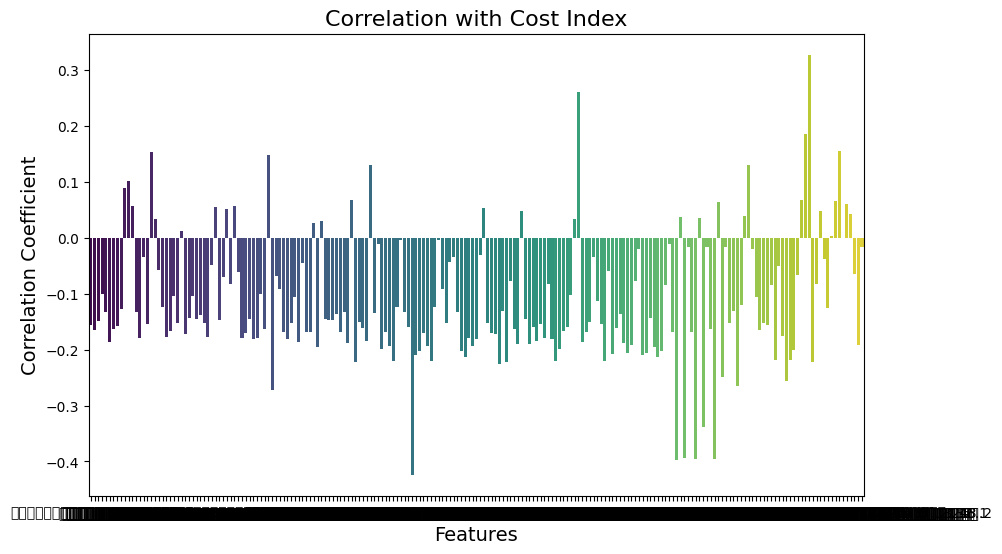

In [24]:
df_factor_district=df_factor.copy()
df_factor = df_factor.iloc[:, 4:]
df_factor = df_factor.apply(pd.to_numeric, errors='coerce')
correlation_matrix = df_factor.corr()

# 提取与 'cost index' 列的相关系数
cost_index_correlation = correlation_matrix['cost index'].drop('cost index')

# 可视化相关系数
plt.figure(figsize=(10, 6))
sns.barplot(x=cost_index_correlation.index, y=cost_index_correlation.values, palette='viridis')
plt.title('Correlation with Cost Index', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.xticks(rotation=45, ha='right', fontproperties=font_prop, fontsize=4)
plt.axhline(0, color='gray', linestyle='--')
plt.show()

In [25]:
cost_index_correlation

總人口                                -0.156640
按性別劃分的人口                           -0.164892
按性別劃分的人口.1                         -0.148616
性別比率（即男性數目與每千名女性相對的比率）             -0.100692
按年齡組別劃分的人口                         -0.133037
                                      ...   
按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2     0.059406
按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3     0.041817
按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口     -0.064271
按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1   -0.192620
按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2   -0.016814
Name: cost index, Length: 205, dtype: float64

In [26]:
sorted_correlation = cost_index_correlation.abs().sort_values(ascending=False)

# 列出前20个字段
top_20_fields = sorted_correlation.head(20)
print(top_20_fields)

按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2           0.423640
按房屋類型劃分的有人居住的屋宇單位數目.1                         0.396642
按房屋類型劃分的家庭住戶數目.1                              0.396406
按房屋類型劃分的人口.1                                  0.394730
按房屋類型劃分的有人居住的屋宇單位數目.3                         0.394391
按房屋類型劃分的家庭住戶數目.3                              0.337991
家庭住戶每月按揭供款及借貸還款與收入比率中位數                       0.326840
按上課地點劃分的於香港院校就讀全日制課程的人口.2                     0.272985
按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2                    0.264251
家庭住戶平均人數                                      0.260775
按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2    0.256533
按房屋類型劃分的人口.3                                  0.248926
按行業(9)劃分的工作人口.3                               0.225899
按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目                 0.222602
按行業(9)劃分的工作人口.5                               0.222094
按工作地點劃分的工作人口.2                                0.221762
按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4            0.221243
按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4     0.221243
按住戶人數劃分的家庭

In [38]:
top_20_columns = top_20_fields.index.tolist()

# 将 '區議會分區（中文名稱)' 和 top_20_fields 的字段组合成一个新的 DataFrame
selected_columns = ['區議會分區（中文名稱)'] + top_20_columns
new_df = df_factor_district[selected_columns]
new_df['區議會分區（中文名稱)']=np.array(['中西區', '灣仔', '東區', '南區', '油尖旺', '深水埗', '九龍城', '黃大仙', '觀塘', '葵青', '荃灣', '屯門', '元朗'
                                 , '北區', '大埔', '沙田', '西貢', '離島'])

C:\Users\非衣\AppData\Local\Temp\ipykernel_12760\1921908722.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['區議會分區（中文名稱)']=np.array(['中西區', '灣仔', '東區', '南區', '油尖旺', '深水埗', '九龍城', '黃大仙', '觀塘', '葵青', '荃灣', '屯門', '元朗'


In [43]:
new_df[new_df['區議會分區（中文名稱)']=='灣仔'].head()

,區議會分區（中文名稱),按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2,按房屋類型劃分的有人居住的屋宇單位數目.1,按房屋類型劃分的家庭住戶數目.1,按房屋類型劃分的人口.1,按房屋類型劃分的有人居住的屋宇單位數目.3,按房屋類型劃分的家庭住戶數目.3,家庭住戶每月按揭供款及借貸還款與收入比率中位數,按上課地點劃分的於香港院校就讀全日制課程的人口.2,按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2,...,按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2,按房屋類型劃分的人口.3,按行業(9)劃分的工作人口.3,按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目,按行業(9)劃分的工作人口.5,按工作地點劃分的工作人口.2,按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4,按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4,按住戶人數劃分的家庭住戶數目,按住戶結構劃分的家庭住戶數目.6
1,灣仔,15000,-,-,-,407,293,21.4,1799,20369,...,211,1632,2807,2496,4532,10759,7238,7238,17579,17579


In [44]:
new_df=new_df.drop(columns=['按房屋類型劃分的有人居住的屋宇單位數目.1','按房屋類型劃分的家庭住戶數目.1','按房屋類型劃分的人口.1'])

In [45]:
BUS_FE=pd.read_excel('../Data/BUS/Bus_FE.xlsx',engine='openpyxl')
merged_df = pd.merge(BUS_FE,new_df, how='left', left_on='ON_DISTRICT', right_on='區議會分區（中文名稱)')




In [51]:
merged_df.head()

,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,...,按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2,按房屋類型劃分的人口.3,按行業(9)劃分的工作人口.3,按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目,按行業(9)劃分的工作人口.5,按工作地點劃分的工作人口.2,按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4,按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4,按住戶人數劃分的家庭住戶數目,按住戶結構劃分的家庭住戶數目.6
0,271,1001,1,17,25,5.8,1,KMB,R,0,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041
1,152,1001,1,8,14,6.7,1,KMB,R,0,...,1051,4721,11877,12214,8010,53720,17962,17962,32089,32089
2,254,1001,1,15,25,6.7,1,KMB,R,0,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041
3,5,1001,1,1,7,6.7,1,KMB,R,0,...,1663,3591,16226,26350,7533,62624,15576,15576,29032,29032
4,525,1001,2,13,17,6.3,1,KMB,R,0,...,1051,4721,11877,12214,8010,53720,17962,17962,32089,32089


In [54]:
merged_df.to_excel("../Data/BUS/Bus_FE.xlsx",engine="openpyxl")

In [10]:
file_path_3 = '../Data/Bus/SelectedRoute.xlsx'
df_select = pd.read_excel(file_path_3, engine='openpyxl')
df_select.head()

,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,...,STOP_NAMES_y,OFF_SEQ_STOP_ID,ON_STOP_X,ON_STOP_Y,OFF_STOP_X,OFF_STOP_Y,ON_DISTRICT,OFF_DISTRICT,DISTANCE,COST_INDEX
0,271,1001,1,17,25,5.8,1,KMB,R,0,...,尖沙咀码头,4025,835531,819900,835463,817244,油尖旺,油尖旺,2724,0.024715
1,152,1001,1,8,14,6.7,1,KMB,R,0,...,拔萃男书院,4014,837429,821474,836023,820663,九龍城,九龍城,2217,0.023813
2,254,1001,1,15,25,6.7,1,KMB,R,0,...,尖沙咀码头,4025,835862,820632,835463,817244,油尖旺,油尖旺,3787,0.039692
3,5,1001,1,1,7,6.7,1,KMB,R,0,...,盈东楼,8090,837872,822918,837727,821666,黃大仙,黃大仙,1397,0.025438
4,525,1001,2,13,17,6.3,1,KMB,R,0,...,东宝庭道,4039,836322,820884,837258,821296,九龍城,九龍城,1348,0.013615


In [12]:
df_select = df_select[['ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ', 'OFF_SEQ', 'PRICE', 'COMPANY_CODE', 'SERVICE_MODE', 'SPECIAL_TYPE', 'ON_DISTRICT', 'OFF_DISTRICT', 'DISTANCE']]
df_select.head()

,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,ON_DISTRICT,OFF_DISTRICT,DISTANCE
0,1001,1,17,25,5.8,KMB,R,0,油尖旺,油尖旺,2724
1,1001,1,8,14,6.7,KMB,R,0,九龍城,九龍城,2217
2,1001,1,15,25,6.7,KMB,R,0,油尖旺,油尖旺,3787
3,1001,1,1,7,6.7,KMB,R,0,黃大仙,黃大仙,1397
4,1001,2,13,17,6.3,KMB,R,0,九龍城,九龍城,1348


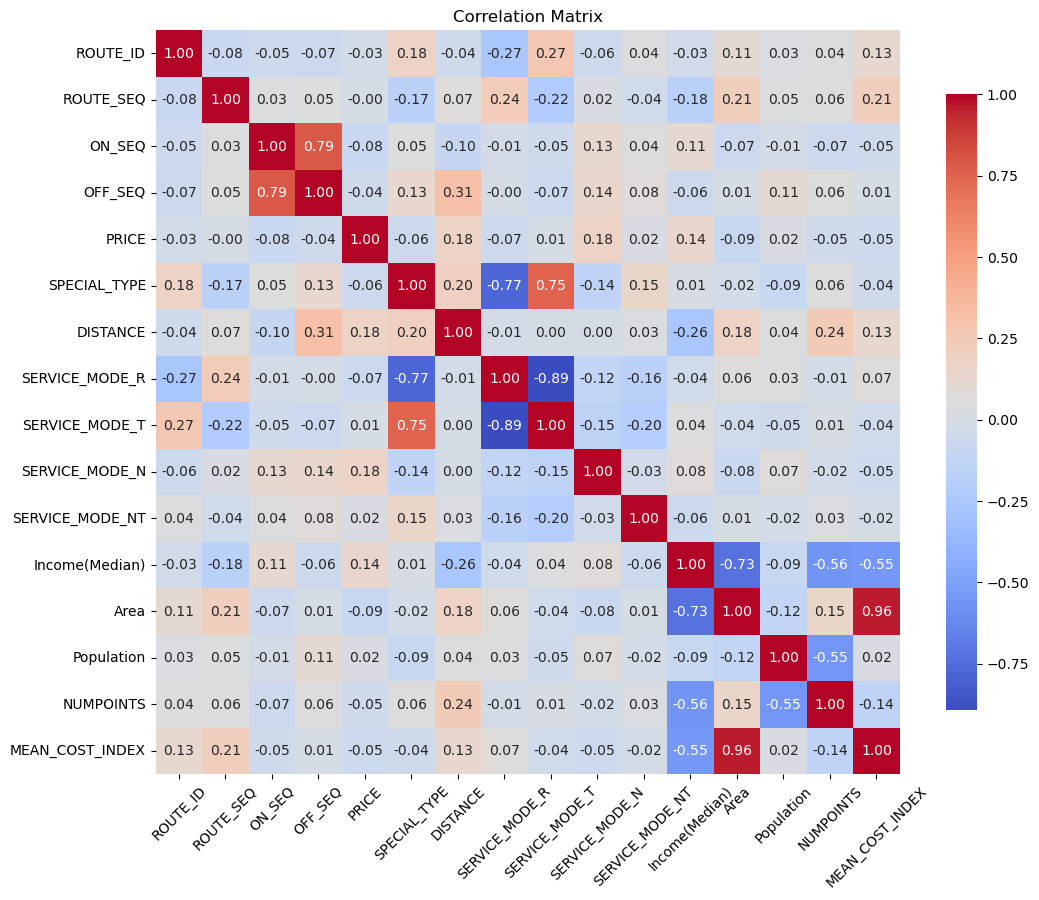

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_select['SERVICE_MODE_R'] = np.where(df_select['SERVICE_MODE'] == 'R', 1, 0)
df_select['SERVICE_MODE_T'] = np.where(df_select['SERVICE_MODE'] == 'T', 1, 0)
df_select['SERVICE_MODE_N'] = np.where(df_select['SERVICE_MODE'] == 'N', 1, 0)
df_select['SERVICE_MODE_NT'] = np.where(df_select['SERVICE_MODE'] == 'NT', 1, 0)

file_path_4 = '../Data/Factors/Organized.xlsx'
df_organize = pd.read_excel(file_path_4, engine='openpyxl')
result = pd.merge(df_select, df_organize, left_on = 'ON_DISTRICT', right_on = '區議會分區', how = 'left')

file_path_5 = '../Data/Factors/Count.xlsx'
df_count = pd.read_excel(file_path_5, engine='openpyxl')
result = pd.merge(result, df_count, left_on = 'ON_DISTRICT', right_on = '地區', how = 'left')

result = result[['ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ', 'OFF_SEQ', 'PRICE', 'SPECIAL_TYPE', 'DISTANCE', 'SERVICE_MODE_R', 'SERVICE_MODE_T', 'SERVICE_MODE_N', 'SERVICE_MODE_NT', 'Income(Median)', 'Area', 'Population', 'NUMPOINTS', 'MEAN_COST_INDEX']]



correlation_matrix = result.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.xticks(rotation=45)


plt.show() 

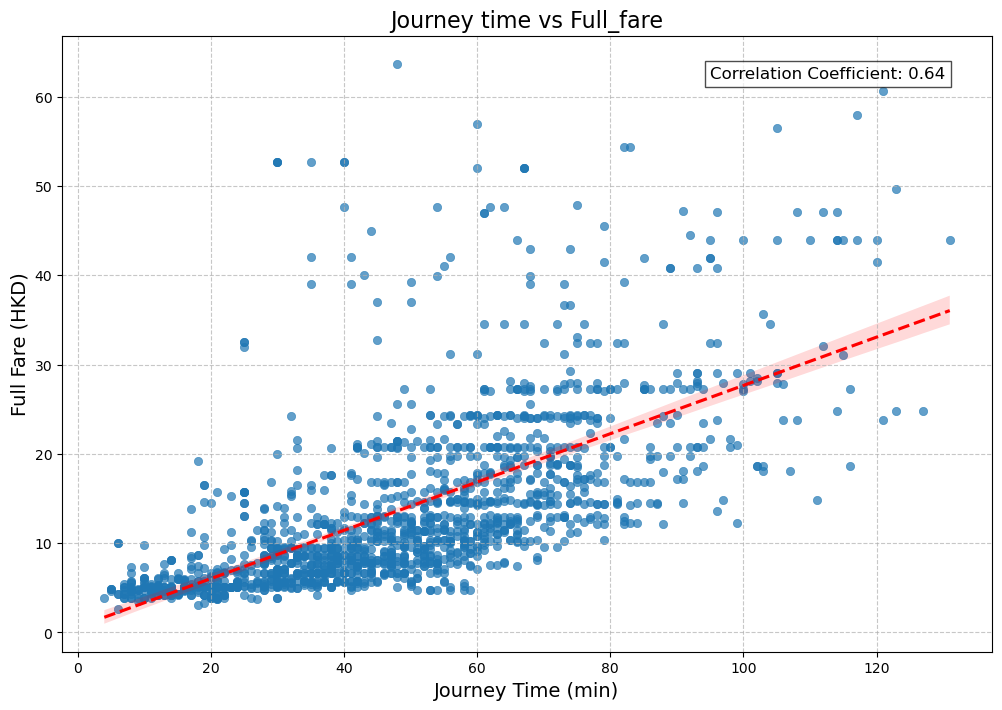

In [50]:
file_path = '../Data/Bus/ROUTE.xlsx'
df_route = pd.read_excel(file_path, engine='openpyxl')
correlation_coeff = df_route['JOURNEY_TIME'].corr(df_route['FULL_FARE'])

plt.figure(figsize=(12, 8))  
sns.scatterplot(data=df_route, x='JOURNEY_TIME', y='FULL_FARE', alpha=0.7, edgecolor=None)

# 添加回归线
sns.regplot(data=df_route, x='JOURNEY_TIME', y='FULL_FARE', scatter=False, color='red', line_kws={"linestyle": "--"})

# 设置标题和标签
plt.title('Journey time vs Full_fare', fontsize=16)
plt.xlabel('Journey Time (min)', fontsize=14)
plt.ylabel('Full Fare (HKD)', fontsize=14)

plt.text(0.95, 0.95, f'Correlation Coefficient: {correlation_coeff:.2f}', 
         horizontalalignment='right', verticalalignment='top', 
         transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))


# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.show()

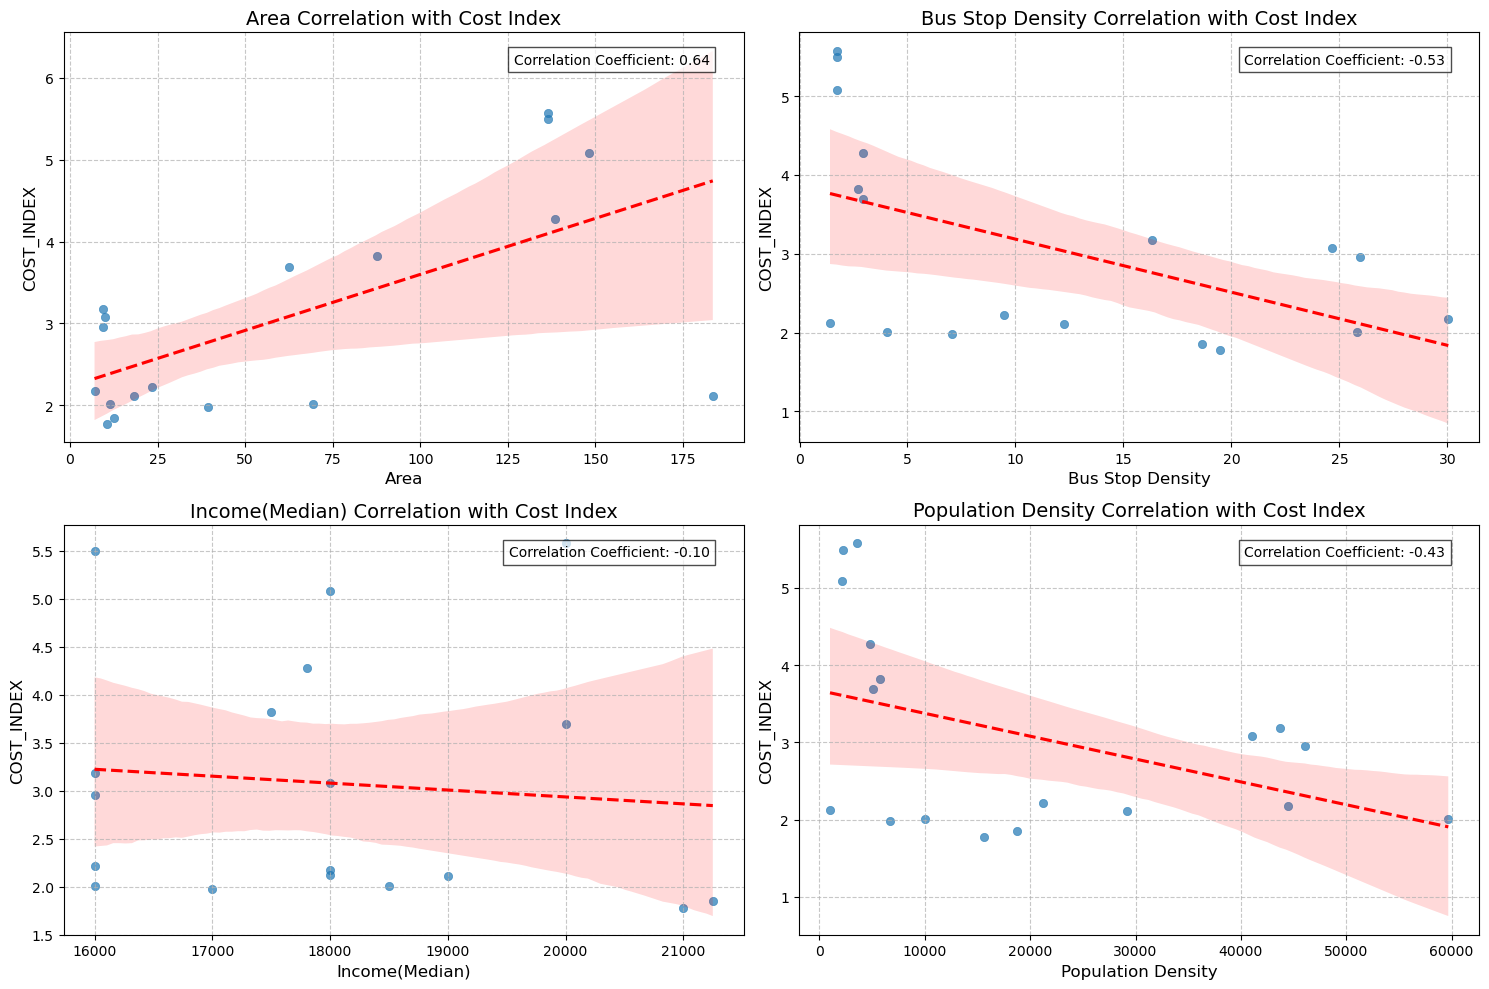

In [80]:
variables = ['Area', 'Bus Stop Density', 'Income(Median)', 'Population Density']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # 将 2D 数组展平，以便迭代

# 绘制每个变量与 COST_INDEX 的关系
for i, var in enumerate(variables):
    # 计算相关系数
    correlation_coeff = df_organize['MEAN_COST_INDEX'].corr(df_organize[var])
    
    # 绘制散点图
    sns.scatterplot(data=df_organize, x=var, y='MEAN_COST_INDEX', ax=axes[i], alpha=0.7, edgecolor=None)
    
    # 添加回归线
    sns.regplot(data=df_organize, x=var, y='MEAN_COST_INDEX', ax=axes[i], scatter=False, color='red', line_kws={"linestyle": "--"})
    
    # 设置标题和标签
    axes[i].set_title(f'{var} Correlation with Cost Index', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('COST_INDEX', fontsize=12)
    
    # 添加网格
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # 在右上角添加相关系数标签
    axes[i].text(0.95, 0.95, f'Correlation Coefficient: {correlation_coeff:.2f}', 
                 horizontalalignment='right', verticalalignment='top', 
                 transform=axes[i].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

# 调整布局
plt.tight_layout()
plt.show()